## Notebook summary

| Item | Details |
| --- | --- |
| Purpose | Knee Joint ROI Detection using YOLOv8 |
| Model / workflow | DenseNet-121/201 |
| Input | not reported |
| Loss | not reported |
| Training / pipeline | YOLO detection/ROI workflow |
| Result | [34m[1mengine/trainer: [0magnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, class...; Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size; [K... |


# Knee Joint ROI Detection using YOLOv8

This notebook trains a YOLOv8 Nano (`yolov8n.pt`) model for Knee Joint Region of Interest (ROI) detection. 
The goal is to automatically detect and crop the knee joint area from wide-view X-ray images, providing a standardized, 
squared input for downstream severity classification models (e.g., DenseNet-201). 

Training strategy: Transfer Learning (Fine-tuning pre-trained COCO weights) on ~800 annotated X-ray images.


## 0. Import libraries & Setup Device
Import Ultralytics, load device, and connect to Google Drive.

In [5]:
import os
import shutil
import yaml
import torch
import cv2
import matplotlib.pyplot as plt

# Try mounting drive (if on Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive mounted successfully.")
except ImportError:
    print("Not running in Google Colab. Skipping Drive mount.")

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

# Install ultralytics if needed
try:
    from ultralytics import YOLO
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "-q", "ultralytics"])
    from ultralytics import YOLO


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully.
Using device: cuda
GPU Name: Tesla T4


## 1. Prepare Dataset & Configuration
Unzip dataset from Google Drive and configure training parameters.

In [6]:
import subprocess

# Unzip dataset from Drive if running on Google Colab
dataset_zip = "/content/drive/MyDrive/Datasets/Knee X-ray Images ROI.zip"
if os.path.exists(dataset_zip):
    print("Unzipping dataset from Google Drive...")
    subprocess.run(["unzip", "-q", dataset_zip, "-d", "/content/Datasets"])
else:
    print("Zip file not found at default Drive path. Assuming local dataset path.")

# =========================================================================
# CONFIGURATION & PARAMETERS (Unified Input Config)
# =========================================================================
class TrainingConfig:
    # Model Selection
    model_name = "yolov8n.pt"         # Use YOLOv8 Nano for fast inference and fine-tuning
    task = "detect"
    
    # Dataset & Paths
    dataset_root = "/content/Datasets" # Equivalent to local 'data/Knee X-ray Images ROI'
    yaml_path = "/content/Datasets/knee_roi.yaml"
    checkpoint_dir = "/content/drive/MyDrive/Models/yolov8_knee_roi_checkpoints"
    
    # Training Parameters
    img_size = 640                    # Standard YOLOv8 image size
    batch_size = 16
    epochs = 50                       # Fine-tuning takes fewer epochs for object detection
    patience = 10                     # Early stopping patience
    seed = 42
    
    # Optimizer & Learning Rate
    optimizer = "auto"                # Ultralytics auto selects optimizer (usually AdamW)
    lr0 = 0.001                       # Initial learning rate
    lrf = 0.01                        # Final learning rate fraction
    weight_decay = 0.0005
    
    # Data Augmentation (YOLOv8 built-in)
    hsv_h = 0.015                     # Image HSV-Hue augmentation
    hsv_s = 0.7                       # Image HSV-Saturation augmentation
    hsv_v = 0.4                       # Image HSV-Value augmentation
    degrees = 10.0                    # Image rotation (+/- deg)
    translate = 0.1                   # Image translation (+/- fraction)
    scale = 0.5                       # Image scale (+/- gain)
    fliplr = 0.5                      # Image flip left-right (probability)
    
print("=================================================================")
print(" ACTIVE YOLOv8 TRAINING CONFIGURATION LOG")
print("=================================================================")
for key, value in TrainingConfig.__dict__.items():
    if not key.startswith("__"):
        print(f"{key:<25} : {value}")
print("=================================================================")


Unzipping dataset from Google Drive...
 ACTIVE YOLOv8 TRAINING CONFIGURATION LOG
model_name                : yolov8n.pt
task                      : detect
dataset_root              : /content/Datasets
yaml_path                 : /content/Datasets/knee_roi.yaml
checkpoint_dir            : /content/drive/MyDrive/Models/yolov8_knee_roi_checkpoints
img_size                  : 640
batch_size                : 16
epochs                    : 50
patience                  : 10
seed                      : 42
optimizer                 : auto
lr0                       : 0.001
lrf                       : 0.01
weight_decay              : 0.0005
hsv_h                     : 0.015
hsv_s                     : 0.7
hsv_v                     : 0.4
degrees                   : 10.0
translate                 : 0.1
scale                     : 0.5
fliplr                    : 0.5


## 2. Create Dataset YAML File
YOLOv8 requires a `.yaml` file defining the paths to the train/val splits and the class names.

In [7]:
# Check if the validation directory is named 'valid' or 'val'
val_dir = 'valid/images' if os.path.exists(os.path.join(TrainingConfig.dataset_root, 'valid')) else 'val/images'

# Create YOLOv8 dataset YAML configuration
dataset_yaml = {
    'path': TrainingConfig.dataset_root,
    'train': 'train/images',
    'val': val_dir,
    'test': 'test/images',  # Optional
    
    'names': {
        0: 'knee'
    }
}

# Ensure directory exists before writing file
os.makedirs(os.path.dirname(TrainingConfig.yaml_path), exist_ok=True)

with open(TrainingConfig.yaml_path, 'w') as f:
    yaml.dump(dataset_yaml, f, sort_keys=False)

print(f"Dataset YAML created at: {TrainingConfig.yaml_path}")
with open(TrainingConfig.yaml_path, 'r') as f:
    print(f.read())


Dataset YAML created at: /content/Datasets/knee_roi.yaml
path: /content/Datasets
train: train/images
val: valid/images
test: test/images
names:
  0: knee



## 3. Train YOLOv8 Model
Initialize the pre-trained weights and begin fine-tuning on the Knee ROI dataset. Ultralytics automatically handles the training loop, learning rate scheduling, and early stopping.

In [8]:
# Initialize model from pre-trained weights
model = YOLO(TrainingConfig.model_name)

# Train the model
print("\n=== STARTING YOLOv8 FINE-TUNING ===")
results = model.train(
    data=TrainingConfig.yaml_path,
    epochs=TrainingConfig.epochs,
    imgsz=TrainingConfig.img_size,
    batch=TrainingConfig.batch_size,
    patience=TrainingConfig.patience,
    optimizer=TrainingConfig.optimizer,
    lr0=TrainingConfig.lr0,
    lrf=TrainingConfig.lrf,
    weight_decay=TrainingConfig.weight_decay,
    seed=TrainingConfig.seed,
    hsv_h=TrainingConfig.hsv_h,
    hsv_s=TrainingConfig.hsv_s,
    hsv_v=TrainingConfig.hsv_v,
    degrees=TrainingConfig.degrees,
    translate=TrainingConfig.translate,
    scale=TrainingConfig.scale,
    fliplr=TrainingConfig.fliplr,
    project=TrainingConfig.checkpoint_dir,
    name='knee_detection_run',
    exist_ok=True, # Overwrite if exists, or set to False to create new run folders
    device=0 if torch.cuda.is_available() else 'cpu'
)

print("\n=== YOLOv8 TRAINING COMPLETED ===")
print(f"Best weights saved at: {os.path.join(TrainingConfig.checkpoint_dir, 'knee_detection_run', 'weights', 'best.pt')}")



=== STARTING YOLOv8 FINE-TUNING ===
Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Datasets/knee_roi.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=knee_detection_run, nbs=64, nms=False, opset

## 4. Evaluate Model Performance
Validate the trained model on the validation split to compute mAP (mean Average Precision).

In [9]:
# Load the best trained weights
best_model_path = os.path.join(TrainingConfig.checkpoint_dir, 'knee_detection_run', 'weights', 'best.pt')
if os.path.exists(best_model_path):
    best_model = YOLO(best_model_path)
    
    # Run validation
    print("\n=== STARTING VALIDATION ===")
    metrics = best_model.val()
    
    print("\n==================================================")
    print("=== FINAL VALIDATION METRICS ===")
    print("==================================================")
    print(f"mAP50-95: {metrics.box.map:.4f}")
    print(f"mAP50:    {metrics.box.map50:.4f}")
    print(f"mAP75:    {metrics.box.map75:.4f}")
    print("==================================================")
else:
    print("Best weights not found. Did training complete successfully?")



=== STARTING VALIDATION ===
Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 840.5±210.3 MB/s, size: 21.8 KB)
val: Scanning /content/Datasets/valid/labels.cache... 315 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 315/315 77.7Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 13, len(boxes) = 357. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 4.7it/s 4.3s0.1s
                   all        315        357      0.989       0.98      0.988      0.746
Speed: 2.2ms preprocess, 4.5ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /c

## 5. Inference & Automatic Cropping
Test the model on an unseen wide-view X-ray image and automatically crop the knee joint.

Running inference on: /content/Datasets/test/images/NormalG0-98-_png.rf.cf87364f8dca0f89a86976a84071cdb3.jpg

image 1/1 /content/Datasets/test/images/NormalG0-98-_png.rf.cf87364f8dca0f89a86976a84071cdb3.jpg: 640x640 1 knee, 7.2ms
Speed: 3.9ms preprocess, 7.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
Detected 1 knee(s).


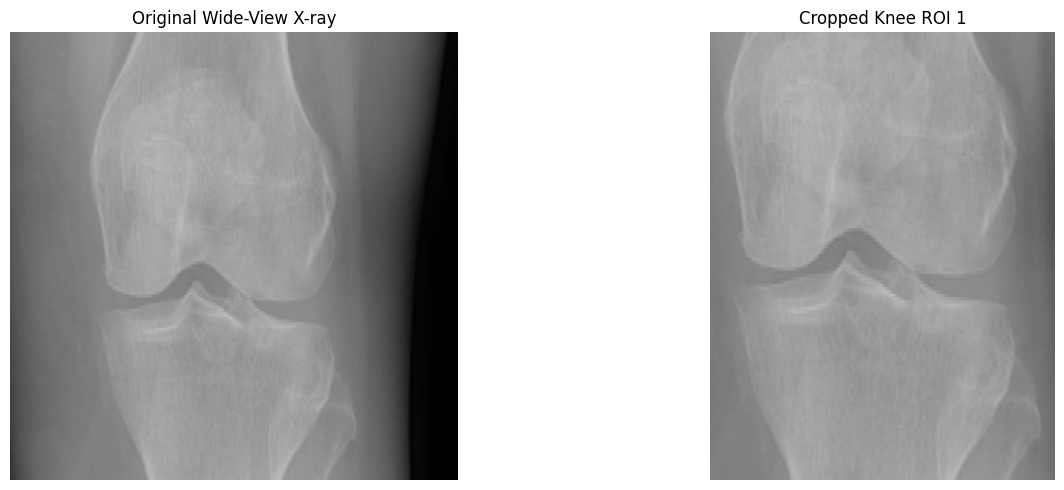

In [10]:
# Load an example test image
# Assuming there is a test image available in the dataset directory
test_image_dir = os.path.join(TrainingConfig.dataset_root, 'test/images')
if os.path.exists(test_image_dir) and len(os.listdir(test_image_dir)) > 0:
    sample_image_path = os.path.join(test_image_dir, os.listdir(test_image_dir)[0])
    
    print(f"Running inference on: {sample_image_path}")
    
    # Run prediction
    results = best_model.predict(source=sample_image_path, conf=0.5, save=False)
    
    # Read original image for cropping
    original_img = cv2.imread(sample_image_path)
    original_img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    
    # Get bounding boxes
    boxes = results[0].boxes
    print(f"Detected {len(boxes)} knee(s).")
    
    fig, axes = plt.subplots(1, len(boxes) + 1, figsize=(15, 5))
    axes[0].imshow(original_img_rgb)
    axes[0].set_title("Original Wide-View X-ray")
    axes[0].axis('off')
    
    # Crop and display each detected knee
    for i, box in enumerate(boxes):
        # YOLO returns coordinates as [x_min, y_min, x_max, y_max]
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        
        # Crop the ROI
        knee_crop = original_img_rgb[y1:y2, x1:x2]
        
        # Optional: Pad to square if needed for downstream model
        # knee_crop_padded = SquarePadOpenCV()(knee_crop)
        
        axes[i+1].imshow(knee_crop)
        axes[i+1].set_title(f"Cropped Knee ROI {i+1}")
        axes[i+1].axis('off')
        
    plt.tight_layout()
    plt.show()
else:
    print("No test images found for inference.")
